# Wholesale Customers — Customer Segmentation

## 1. Importing Libraries

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

## 2. Load Data

In [42]:
df = pd.read_csv('Wholesale_customers_data.csv')
print("Shape:", df.shape)
df.head()

Shape: (440, 8)


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [43]:
SPEND_COLS = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

## 3. Exploratory Data Analysis

In [44]:
print(df.info())
print("\nMissing values:", df.isnull().sum().sum())
print("Duplicates:    ", df.duplicated().sum())
df.describe().round(0)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB
None

Missing values: 0
Duplicates:     0


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.0,440.0,440.0,440.0,440.0,440.0,440.0,440.0
mean,1.0,3.0,12000.0,5796.0,7951.0,3072.0,2881.0,1525.0
std,0.0,1.0,12647.0,7380.0,9503.0,4855.0,4768.0,2820.0
min,1.0,1.0,3.0,55.0,3.0,25.0,3.0,3.0
25%,1.0,2.0,3128.0,1533.0,2153.0,742.0,257.0,408.0
50%,1.0,3.0,8504.0,3627.0,4756.0,1526.0,816.0,966.0
75%,2.0,3.0,16934.0,7190.0,10656.0,3554.0,3922.0,1820.0
max,2.0,3.0,112151.0,73498.0,92780.0,60869.0,40827.0,47943.0


In [45]:
print("Skewness per feature:")
df[SPEND_COLS].skew().sort_values(ascending=False).round(2)

Skewness per feature:


Delicassen          11.15
Frozen               5.91
Milk                 4.05
Detergents_Paper     3.63
Grocery              3.59
Fresh                2.56
dtype: float64

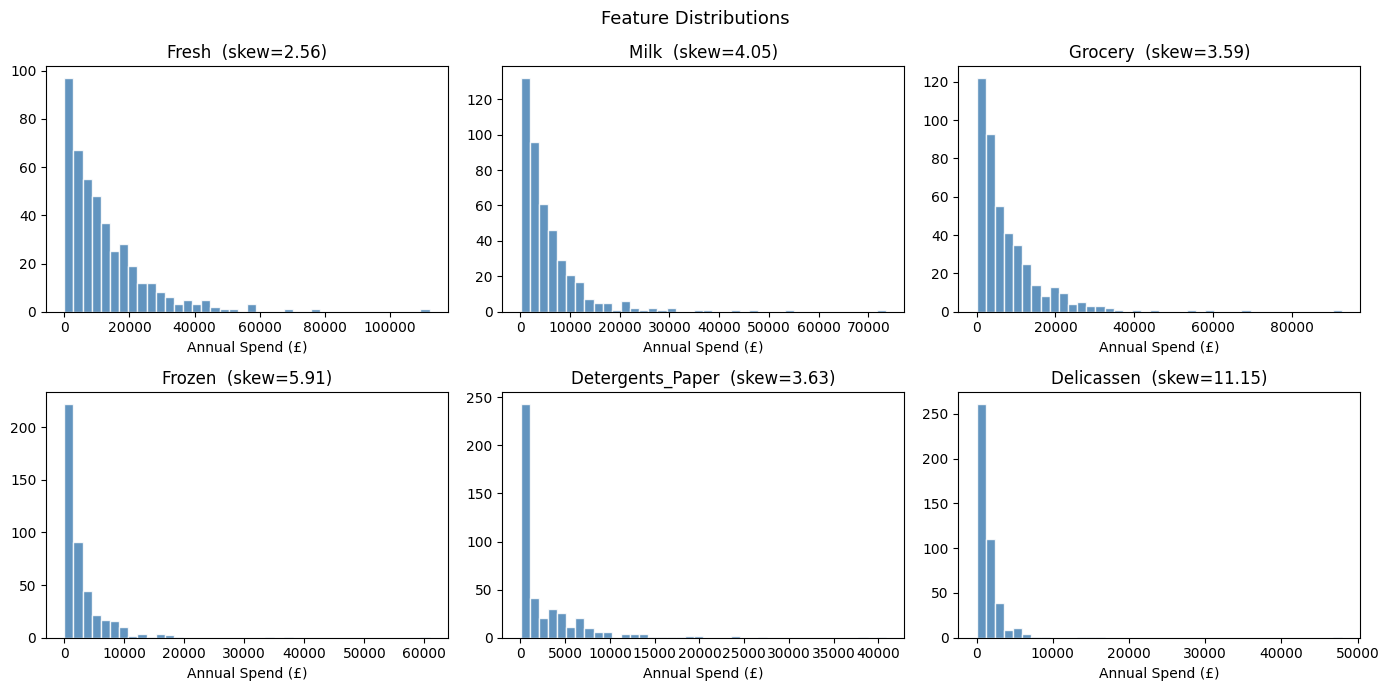

In [46]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for i, col in enumerate(SPEND_COLS):
    axes.flat[i].hist(df[col], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes.flat[i].set_title(f'{col}  (skew={df[col].skew():.2f})')
    axes.flat[i].set_xlabel('Annual Spend (£)')
plt.suptitle('Feature Distributions', fontsize=13)
plt.tight_layout()
plt.show()

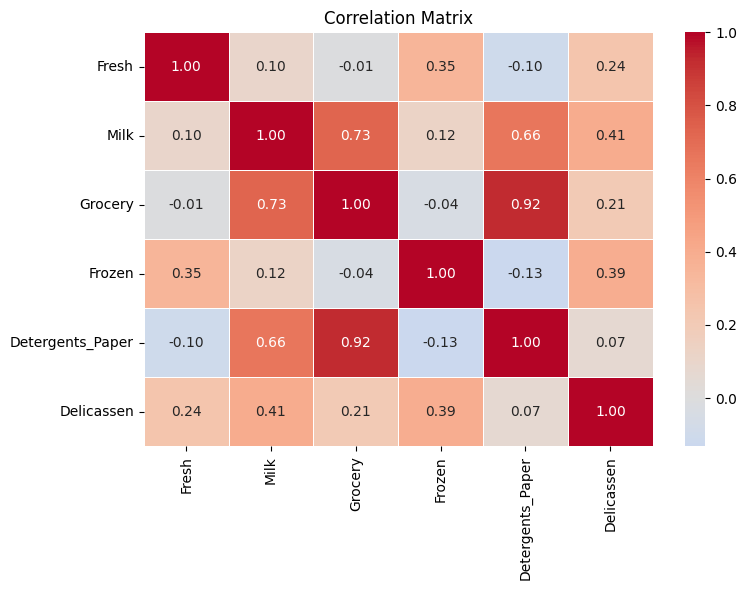

In [47]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[SPEND_COLS].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

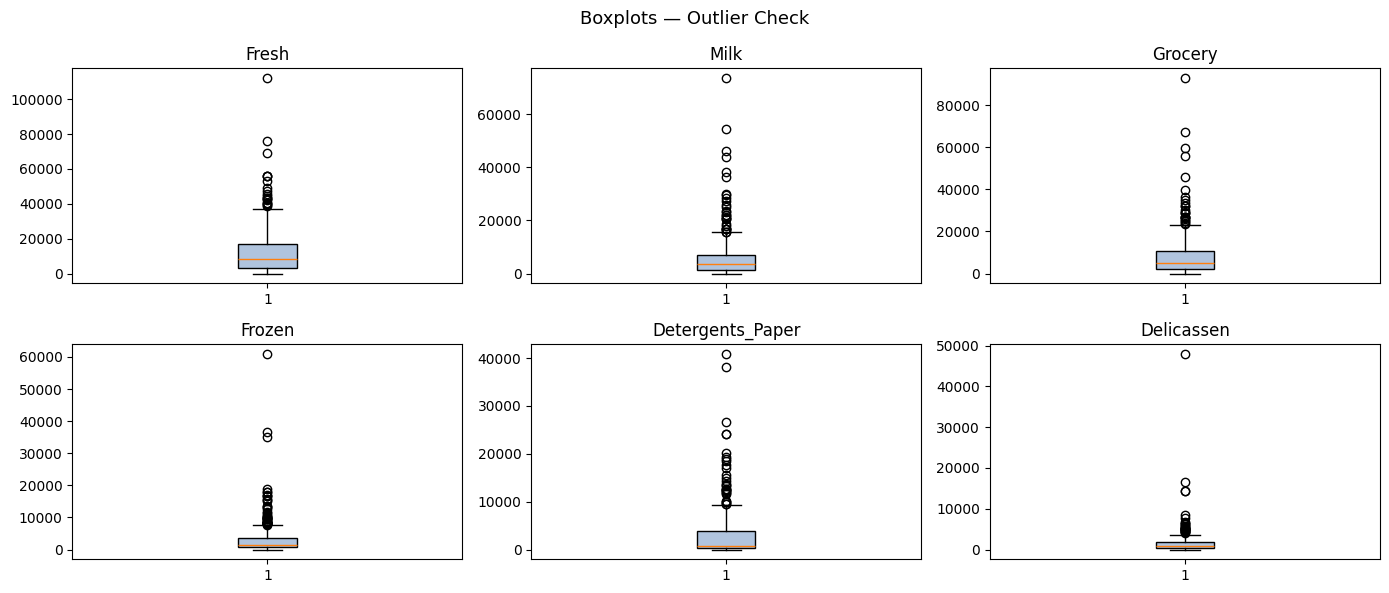

In [48]:
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for i, col in enumerate(SPEND_COLS):
    axes.flat[i].boxplot(df[col], patch_artist=True,
                         boxprops=dict(facecolor='lightsteelblue'))
    axes.flat[i].set_title(col)
plt.suptitle('Boxplots — Outlier Check', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Preprocessing
- `Channel` and `Region` are nominal — dropped from the feature matrix, kept in `df_full` for reference.
- All 6 spending features have skewness > 1 → `log1p` applied before scaling.
- `StandardScaler` ensures all features contribute equally to distance calculations.

In [49]:
df_full = df.copy()
X = df[SPEND_COLS].copy()

In [50]:
X_log = np.log1p(X)

pd.DataFrame({'Skew Before': X.skew().round(2),
              'Skew After':  X_log.skew().round(2)})

,Skew Before,Skew After
Fresh,2.56,-1.58
Milk,4.05,-0.22
Grocery,3.59,-0.67
Frozen,5.91,-0.35
Detergents_Paper,3.63,-0.24
Delicassen,11.15,-1.09


In [51]:
scaler   = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_log), columns=SPEND_COLS)
X_scaled.describe().round(2)

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.00,440.00,440.00,440.00,440.00,440.00
mean,0.00,-0.00,-0.00,0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00
min,-5.00,-3.79,-6.36,-3.16,-3.17,-4.09
25%,-0.47,-0.73,-0.69,-0.54,-0.73,-0.51
50%,0.21,0.07,0.02,0.02,-0.05,0.16
75%,0.68,0.70,0.75,0.68,0.87,0.65
max,1.97,2.86,2.70,2.90,2.24,3.18


## 5. Find Optimal K — Elbow & Silhouette

In [52]:
K_RANGE     = range(2, 11)
inertia     = []
sil_scores  = []

for k in K_RANGE:
    km  = KMeans(n_clusters=k, n_init=15, random_state=RANDOM_STATE)
    lbl = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, lbl))

k_list = list(K_RANGE)
pd.DataFrame({'k': k_list, 'Inertia': inertia,
              'Silhouette': [round(s, 3) for s in sil_scores]})

,k,Inertia,Silhouette
0,2,1844.064069,0.290
1,3,1553.421327,0.259
2,4,1386.862741,0.188
3,5,1266.149362,0.192
4,6,1174.758633,0.201
5,7,1086.358700,0.196
6,8,1024.349201,0.187
7,9,973.141483,0.197
8,10,931.998464,0.191


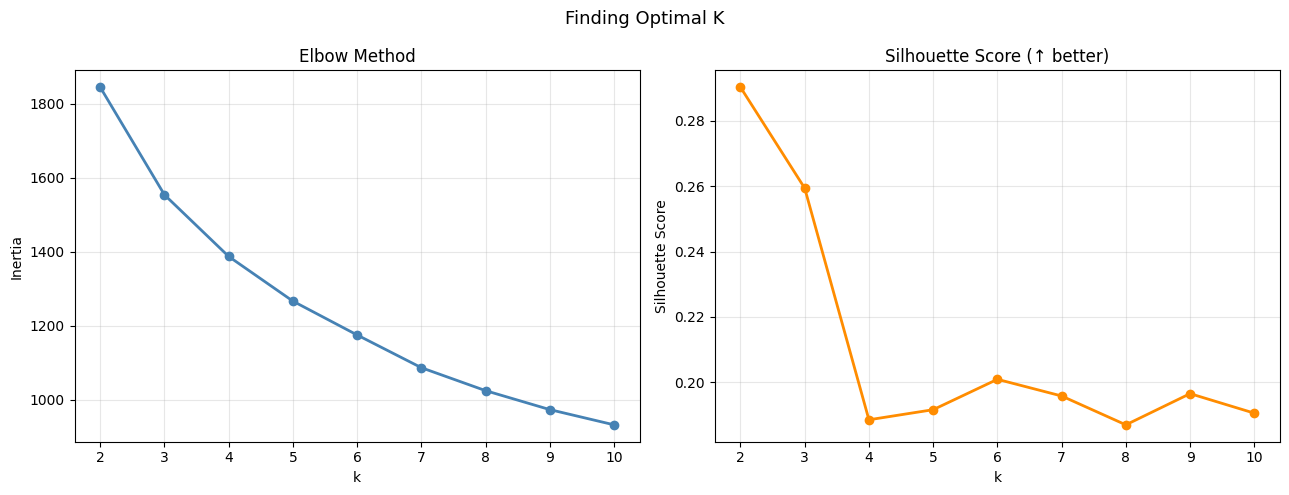

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(k_list, inertia, 'o-', color='steelblue', linewidth=2)
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method'); axes[0].grid(alpha=0.3)

axes[1].plot(k_list, sil_scores, 'o-', color='darkorange', linewidth=2)
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score (↑ better)'); axes[1].grid(alpha=0.3)

plt.suptitle('Finding Optimal K', fontsize=13)
plt.tight_layout()
plt.show()

Silhouette peaks at k=2. However k=3 surfaces a meaningful sub-group and produces more actionable business segments. **Chosen: k=3.**

## 6. Clustering
### 6a. K-Means

In [54]:
OPTIMAL_K    = 3
kmeans       = KMeans(n_clusters=OPTIMAL_K, n_init=15, random_state=RANDOM_STATE)
kmeans_labels = kmeans.fit_predict(X_scaled)

print("Cluster sizes:", dict(zip(*np.unique(kmeans_labels, return_counts=True))))
print(f"Silhouette:    {silhouette_score(X_scaled, kmeans_labels):.3f}")

Cluster sizes: {np.int32(0): np.int64(80), np.int32(1): np.int64(147), np.int32(2): np.int64(213)}
Silhouette:    0.259


### 6b. Hierarchical Clustering

In [55]:
hier        = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
hier_labels = hier.fit_predict(X_scaled)

print("Cluster sizes:", dict(zip(*np.unique(hier_labels, return_counts=True))))
print(f"Silhouette:    {silhouette_score(X_scaled, hier_labels):.3f}")

Cluster sizes: {np.int64(0): np.int64(262), np.int64(1): np.int64(53), np.int64(2): np.int64(125)}
Silhouette:    0.255


### 6c. DBSCAN

In [56]:
dbscan     = DBSCAN(eps=0.8, min_samples=5)
db_labels  = dbscan.fit_predict(X_scaled)
n_noise    = (db_labels == -1).sum()
n_clusters = len(set(db_labels)) - 1
mask       = db_labels != -1

print(f"Clusters found: {n_clusters}")
print(f"Noise points:   {n_noise} ({n_noise/len(db_labels):.0%} of dataset)")
if n_clusters >= 2:
    print(f"Silhouette (non-noise): {silhouette_score(X_scaled[mask], db_labels[mask]):.3f}")

Clusters found: 3
Noise points:   230 (52% of dataset)
Silhouette (non-noise): 0.288


## 7. Cluster Profiling

In [57]:
df_full['cluster'] = kmeans_labels

print("Cluster sizes:")
print(df_full['cluster'].value_counts().sort_index())

Cluster sizes:
cluster
0     80
1    147
2    213
Name: count, dtype: int64


In [58]:
mean_profile = df_full.groupby('cluster')[SPEND_COLS].mean().round(0)
med_profile  = df_full.groupby('cluster')[SPEND_COLS].median().round(0)

print("Mean spend per cluster (£):")
print(mean_profile)
print("\nMedian spend per cluster (£):")
print(med_profile)

Mean spend per cluster (£):
           Fresh     Milk  Grocery  Frozen  Detergents_Paper  Delicassen
cluster                                                                 
0         2899.0   7136.0  12570.0   607.0            5554.0       783.0
1        17043.0  10560.0  13334.0  4133.0            4987.0      2847.0
2        11939.0   2006.0   2502.0  3266.0             424.0       891.0

Median spend per cluster (£):
           Fresh    Milk  Grocery  Frozen  Detergents_Paper  Delicassen
cluster                                                                
0         1492.0  6300.0  10502.0   376.0            4218.0       434.0
1        12126.0  7184.0   9965.0  2005.0            3378.0      2005.0
2         9612.0  1601.0   2155.0  2121.0             274.0       686.0


## 8. PCA Visualisation

In [59]:
pca   = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
var   = pca.explained_variance_ratio_
print(f"Variance explained — PC1: {var[0]:.2%}  PC2: {var[1]:.2%}  Total: {sum(var):.2%}")

Variance explained — PC1: 44.08%  PC2: 27.19%  Total: 71.27%


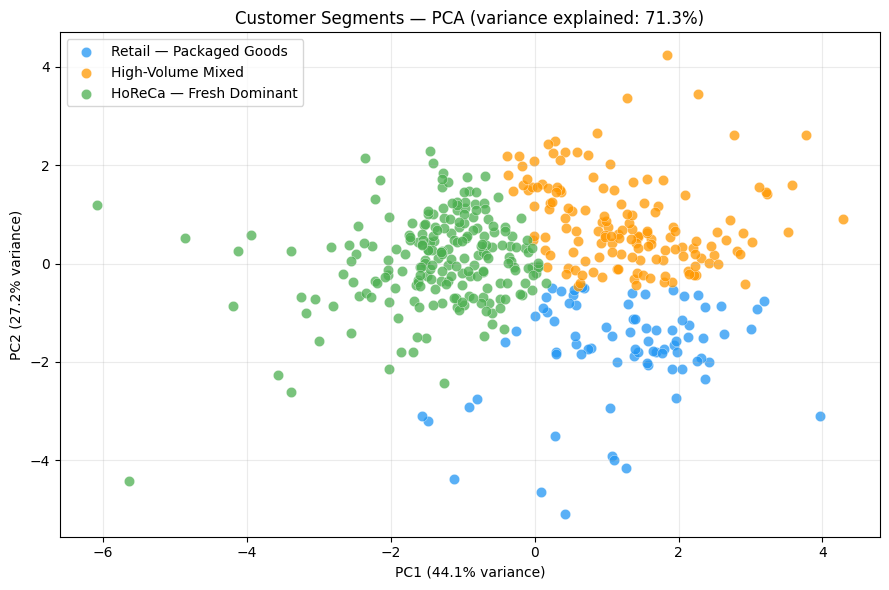

In [60]:
CLUSTER_NAMES = {0: 'Retail — Packaged Goods',
                 1: 'High-Volume Mixed',
                 2: 'HoReCa — Fresh Dominant'}
COLORS = {0: '#2196F3', 1: '#FF9800', 2: '#4CAF50'}

plt.figure(figsize=(9, 6))
for c in range(OPTIMAL_K):
    m = kmeans_labels == c
    plt.scatter(X_pca[m, 0], X_pca[m, 1], c=COLORS[c],
                label=CLUSTER_NAMES[c], s=55, alpha=0.75,
                edgecolors='white', linewidths=0.3)

plt.xlabel(f'PC1 ({var[0]:.1%} variance)')
plt.ylabel(f'PC2 ({var[1]:.1%} variance)')
plt.title(f'Customer Segments — PCA (variance explained: {sum(var):.1%})')
plt.legend(); plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### Segment Descriptions

| Cluster | Size | Segment | Description |
|---------|------|---------|-------------|
| **0** | 80 | **Retail — Packaged Goods** | Highest Grocery and Detergents_Paper spend. Lowest Fresh. Supermarkets and convenience stores buying shelf-stable products. |
| **1** | 147 | **High-Volume Mixed** | Highest Fresh and Milk spend. High across all categories. Large-format retailers or catering companies with broad purchasing needs. |
| **2** | 213 | **HoReCa(Hotel , Restaurant , Cafe) — Fresh Dominant** | Nearly all HoReCa channel. Highest Fresh, lowest Grocery and Detergents. Classic restaurant and café profile. |